# Earthquake Damage Prediction — Cleaned Notebook

This version removes duplicate cells and fixes two real bugs found in the original:

1. **`best_rf` was never updated after `GridSearchCV`** — the notebook ran a full hyperparameter search but kept evaluating/saving the *untuned baseline* Random Forest. Fixed by setting `best_rf = grid_search.best_estimator_` after the search.
2. **Model comparison table had a copy-paste bug** — the "Random Forest" row used `dt_accuracy` (Decision Tree's score) instead of the Random Forest's own score. Also removed a fake "XGBoost" row — no XGBoost model was ever actually trained in the original notebook (the cell under that heading only re-built the label encoders).

Duplicate `encoders` creation, duplicate `.pkl` saves, and a broken/premature save cell (referencing an undefined `xgb_label_encoder`) have also been removed. There is now exactly **one** save location, at the end, which saves `model.pkl`, `encoders.pkl`, and `feature_columns.pkl` together.


## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


## 2. Load Dataset

Update `DATASET_DIR` below to point at your `dataset` folder if it's in a different location.

In [2]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\manch\OneDrive\Desktop\Earthquake-Damage-Prediction\Notebook
['Earthquake_Damage_Prediction.ipynb', 'feature_importance.csv']


In [3]:
import os
import pandas as pd

# Cross-platform path (was hardcoded Windows-style "..\\dataset" before)
DATASET_DIR = os.path.join("..", "dataset")

train_values = pd.read_csv(os.path.join(DATASET_DIR, "train_values.csv"))
train_labels = pd.read_csv(os.path.join(DATASET_DIR, "train_labels.csv"))

print(train_values.shape)
print(train_labels.shape)

(260601, 39)
(260601, 2)


## 3. Merge Dataset

In [4]:
df = pd.merge(train_values, train_labels, on="building_id")
df.shape


(260601, 40)

## 4. Data Understanding

In [5]:
df.head()


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 

In [7]:
df.isnull().sum()


building_id                               0
geo_level_1_id                            0
geo_level_2_id                            0
geo_level_3_id                            0
count_floors_pre_eq                       0
age                                       0
area_percentage                           0
height_percentage                         0
land_surface_condition                    0
foundation_type                           0
roof_type                                 0
ground_floor_type                         0
other_floor_type                          0
position                                  0
plan_configuration                        0
has_superstructure_adobe_mud              0
has_superstructure_mud_mortar_stone       0
has_superstructure_stone_flag             0
has_superstructure_cement_mortar_stone    0
has_superstructure_mud_mortar_brick       0
has_superstructure_cement_mortar_brick    0
has_superstructure_timber                 0
has_superstructure_bamboo       

In [8]:
df.describe()


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
count,2.606010e+05,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,...,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
mean,5.256755e+05,13.900353,701.074685,6257.876148,2.129723,26.535029,8.018051,5.434365,0.088645,0.761935,...,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119,2.238272
std,3.045450e+05,8.033617,412.710734,3646.369645,0.727665,73.565937,4.392231,1.918418,0.284231,0.425900,...,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364,0.611814
min,4.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.611900e+05,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,5.257570e+05,12.000000,702.000000,6270.000000,2.000000,15.000000,7.000000,5.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,7.897620e+05,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,1.052934e+06,30.000000,1427.000000,12567.000000,9.000000,995.000000,100.000000,32.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


## 5. Data Cleaning

In [9]:
df.dropna(inplace=True)
df = df.drop_duplicates()
print("Duplicates after cleaning:", df.duplicated().sum())
print("Nulls after cleaning:\n", df.isnull().sum().sum())


Duplicates after cleaning: 0
Nulls after cleaning:
 0


In [10]:
df = df.drop('building_id', axis=1)
df.shape


(260601, 39)

## 6. Exploratory Data Analysis (EDA)

damage_grade
2    148259
3     87218
1     25124
Name: count, dtype: int64
damage_grade
2    56.89
3    33.47
1     9.64
Name: proportion, dtype: float64


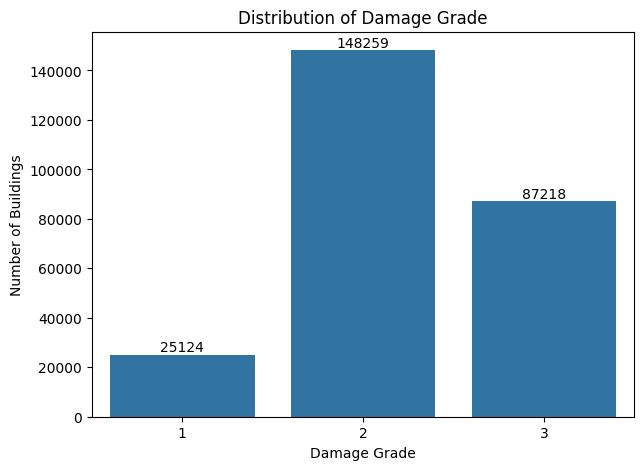

In [11]:
print(df['damage_grade'].value_counts())
print((df['damage_grade'].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(7,5))
ax = sns.countplot(x='damage_grade', data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Distribution of Damage Grade")
plt.xlabel("Damage Grade")
plt.ylabel("Number of Buildings")
plt.show()


count    260601.000000
mean          2.129723
std           0.727665
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           9.000000
Name: count_floors_pre_eq, dtype: float64


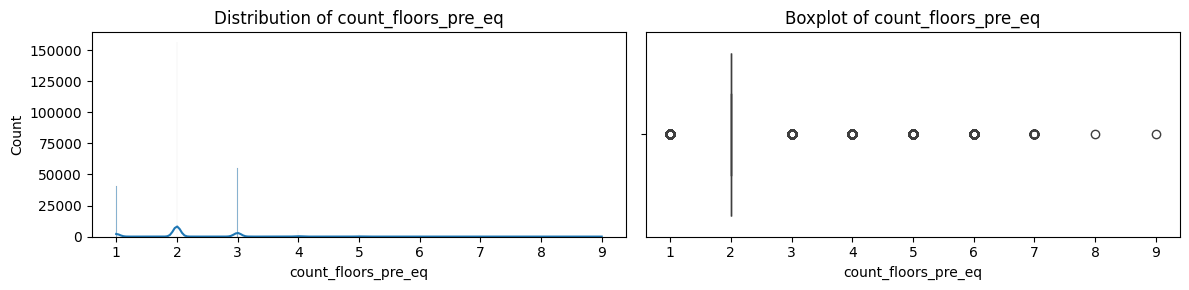

count    260601.000000
mean         26.535029
std          73.565937
min           0.000000
25%          10.000000
50%          15.000000
75%          30.000000
max         995.000000
Name: age, dtype: float64


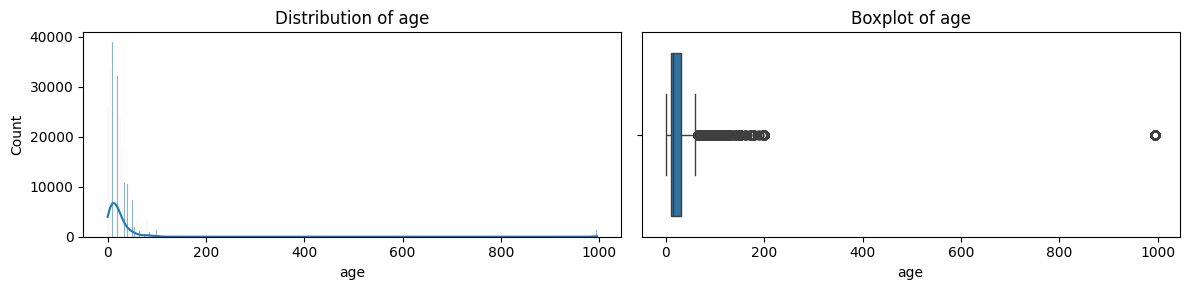

count    260601.000000
mean          8.018051
std           4.392231
min           1.000000
25%           5.000000
50%           7.000000
75%           9.000000
max         100.000000
Name: area_percentage, dtype: float64


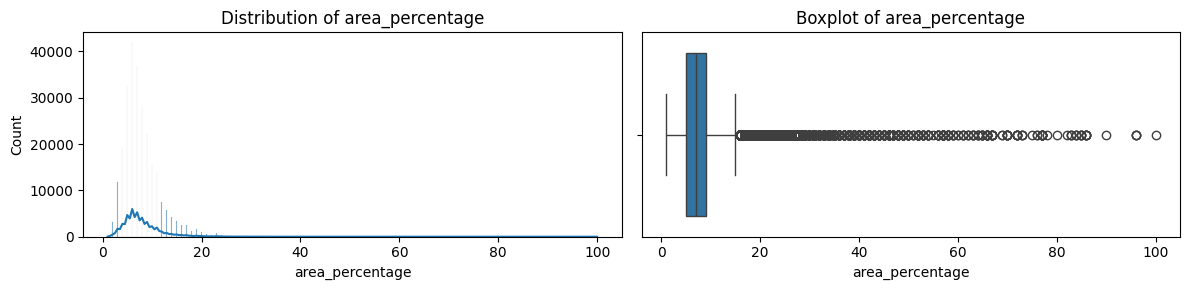

count    260601.000000
mean          5.434365
std           1.918418
min           2.000000
25%           4.000000
50%           5.000000
75%           6.000000
max          32.000000
Name: height_percentage, dtype: float64


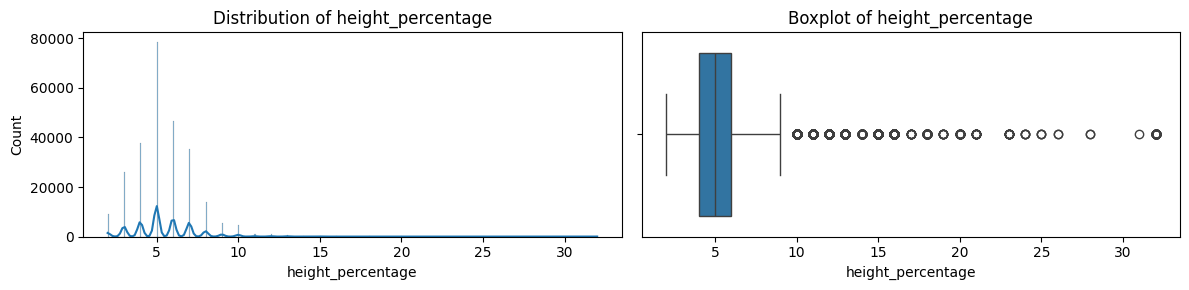

count    260601.000000
mean          0.983949
std           0.418389
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           9.000000
Name: count_families, dtype: float64


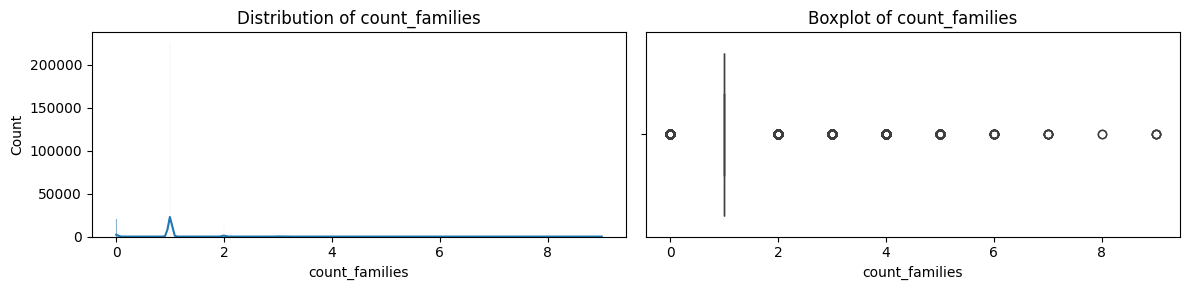

In [12]:
numerical_features = [
    'count_floors_pre_eq',
    'age',
    'area_percentage',
    'height_percentage',
    'count_families'
]

for col in numerical_features:
    print(df[col].describe())
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()


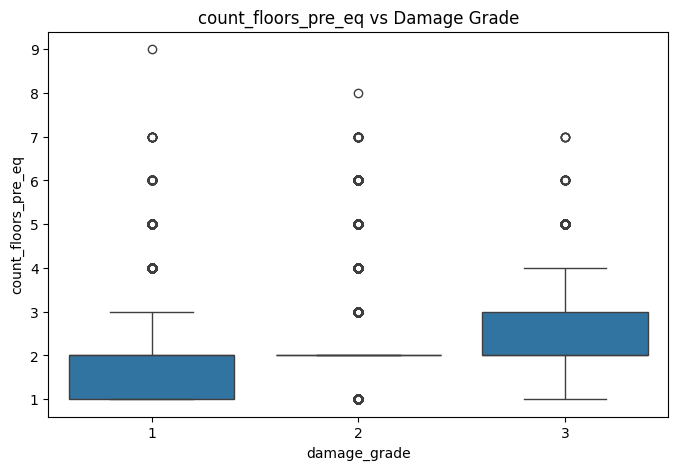

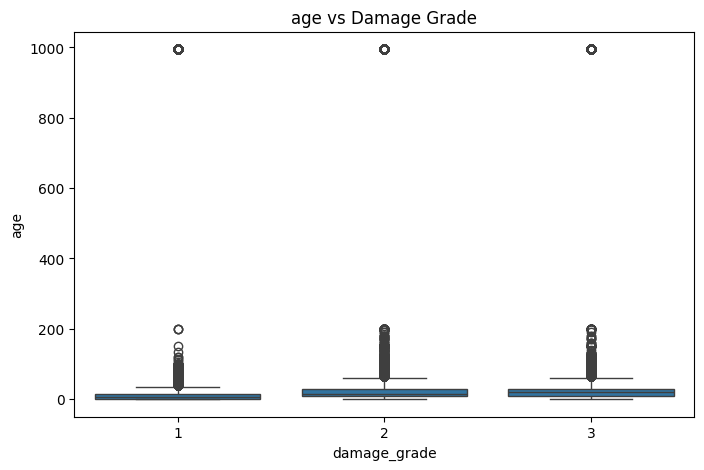

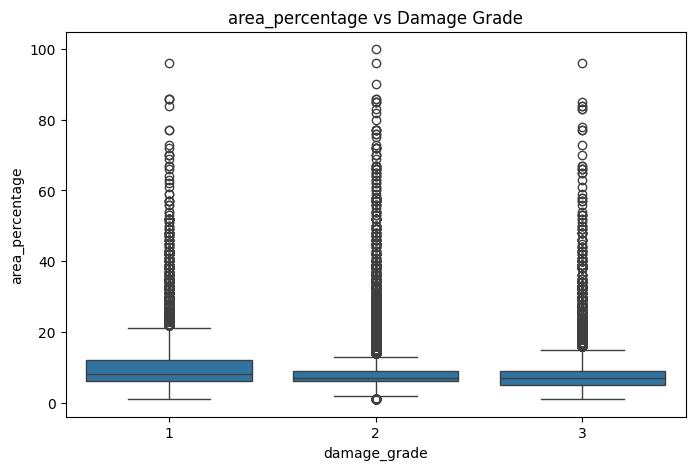

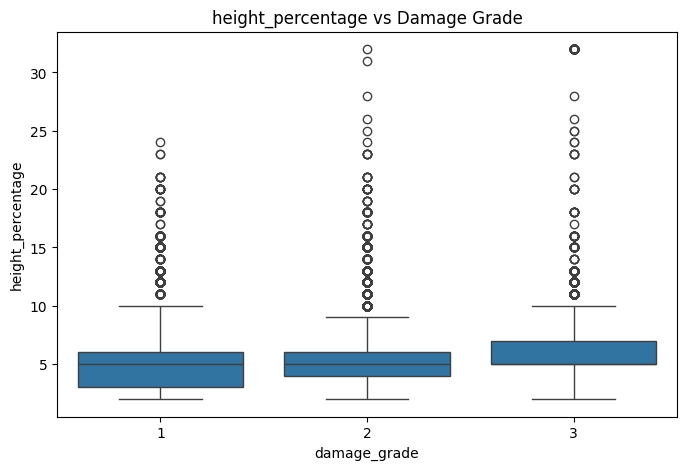

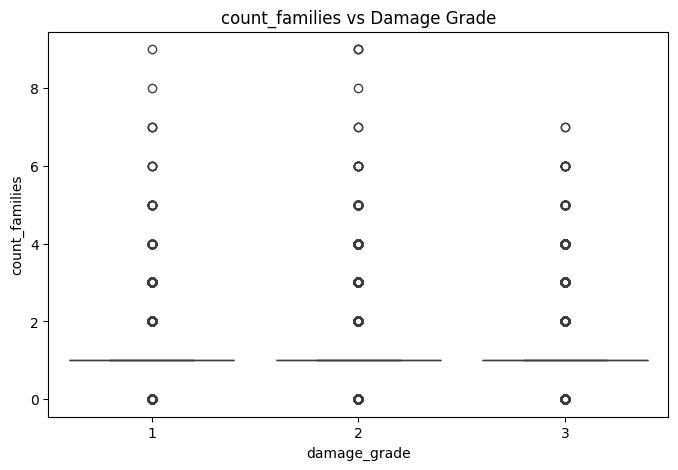

In [13]:
for col in numerical_features:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='damage_grade', y=col, data=df)
    plt.title(f"{col} vs Damage Grade")
    plt.show()


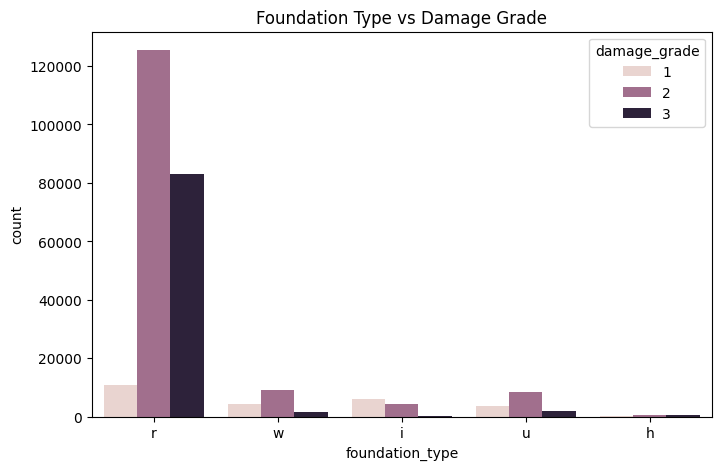

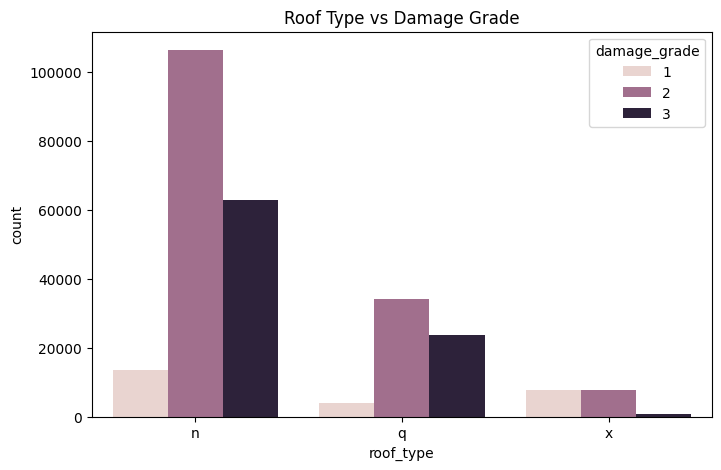

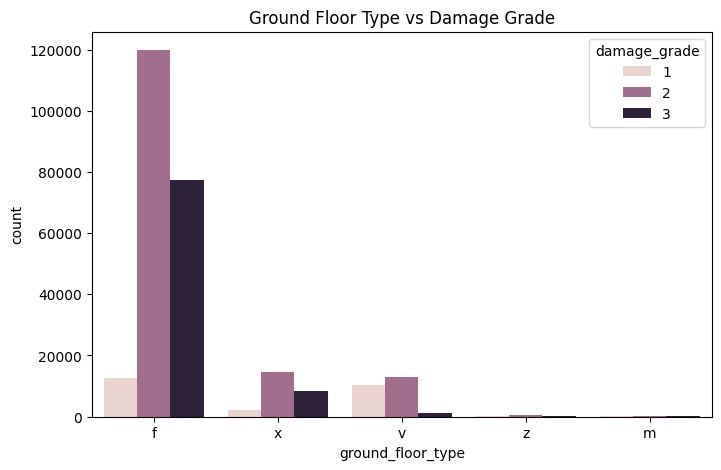

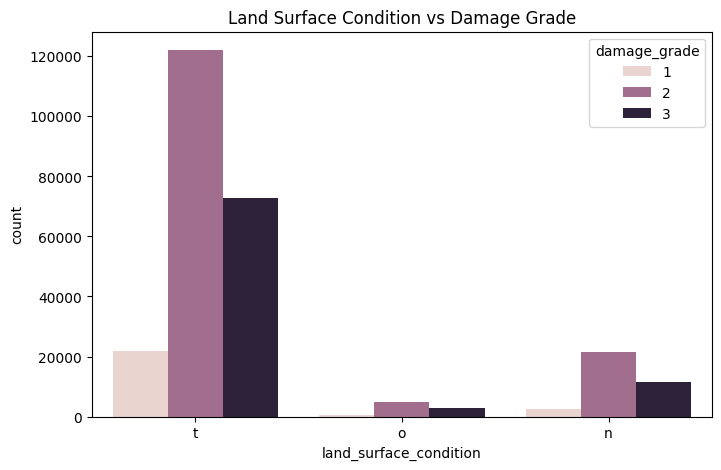

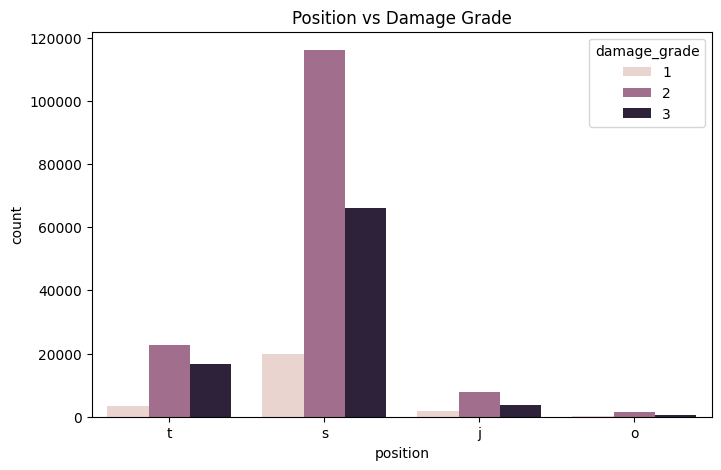

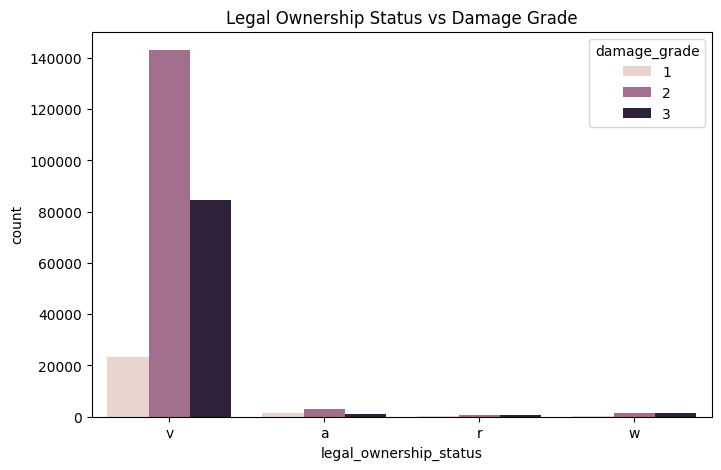

In [14]:
categorical_features = [
    'foundation_type',
    'roof_type',
    'ground_floor_type',
    'land_surface_condition',
    'position',
    'legal_ownership_status'
]

for col in categorical_features:
    plt.figure(figsize=(8,5))
    sns.countplot(x=col, hue='damage_grade', data=df)
    plt.title(f"{col.replace('_',' ').title()} vs Damage Grade")
    plt.show()


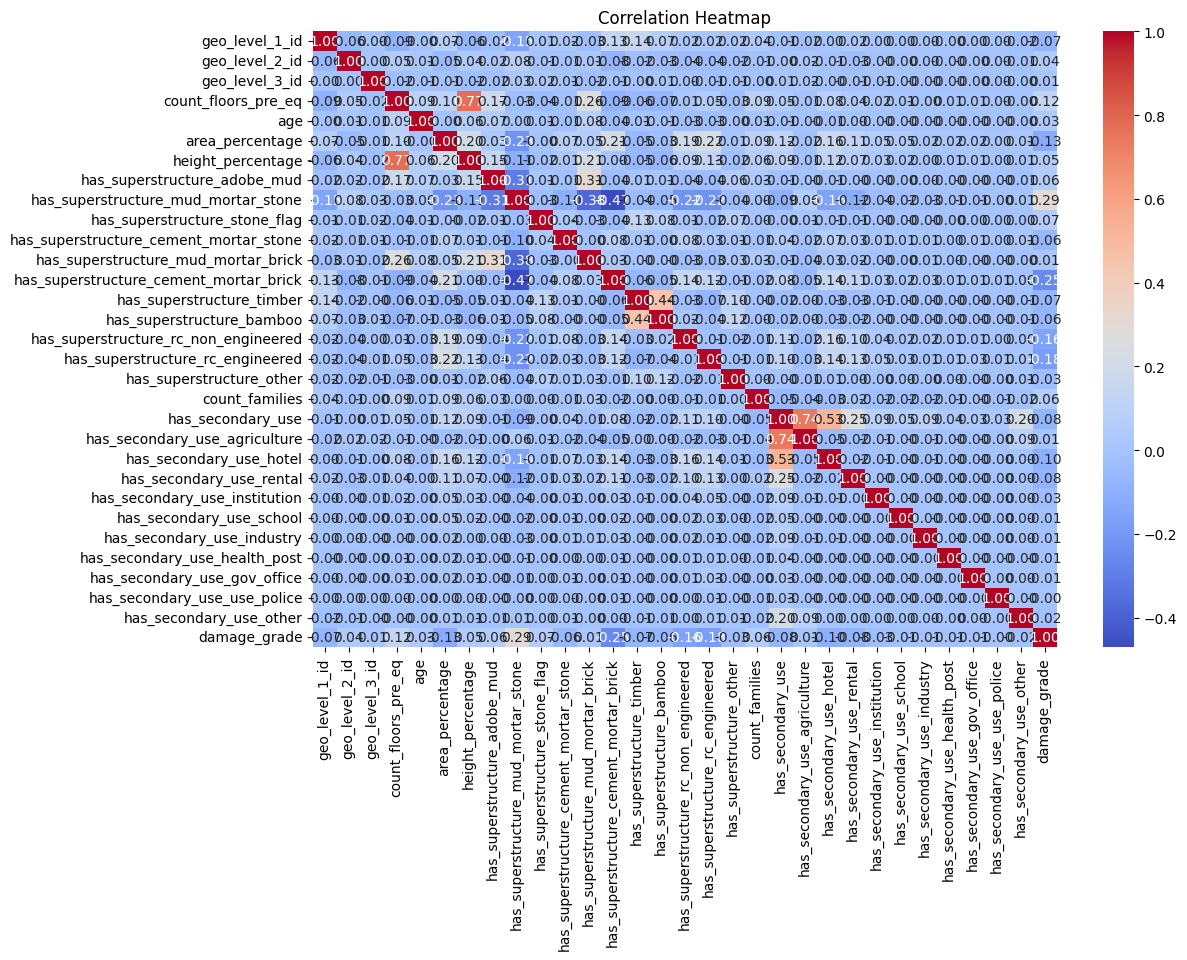

In [15]:
plt.figure(figsize=(12,8))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## 7. Data Preprocessing

In [16]:
X = df.drop('damage_grade', axis=1)
y = df['damage_grade']
print(X.shape, y.shape)


(260601, 38) (260601,)


In [17]:
from sklearn.preprocessing import LabelEncoder
import joblib

encoders = {}

for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()

    X[col] = le.fit_transform(X[col])

    encoders[col] = le

## 8. Train-Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(208480, 38) (52121, 38) (208480,) (52121,)


In [19]:
from sklearn.preprocessing import StandardScaler

# All columns are already numeric (label-encoded above), so scale everything directly.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 9. Model Building

### Logistic Regression

Accuracy: 0.5838913297902957
              precision    recall  f1-score   support

           1       0.57      0.27      0.36      5025
           2       0.59      0.91      0.71     29652
           3       0.54      0.12      0.20     17444

    accuracy                           0.58     52121
   macro avg       0.57      0.43      0.43     52121
weighted avg       0.57      0.58      0.51     52121



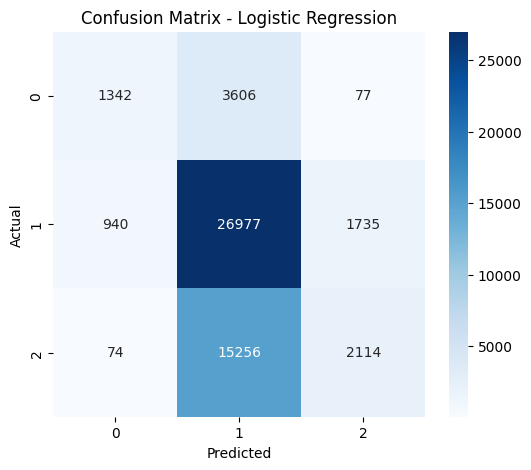

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
log_accuracy = accuracy_score(y_test, y_pred_log)
print("Accuracy:", log_accuracy)
print(classification_report(y_test, y_pred_log))

cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()


### Decision Tree

Accuracy: 0.6596957080639282
              precision    recall  f1-score   support

           1       0.49      0.51      0.50      5025
           2       0.71      0.71      0.71     29652
           3       0.62      0.62      0.62     17444

    accuracy                           0.66     52121
   macro avg       0.61      0.61      0.61     52121
weighted avg       0.66      0.66      0.66     52121



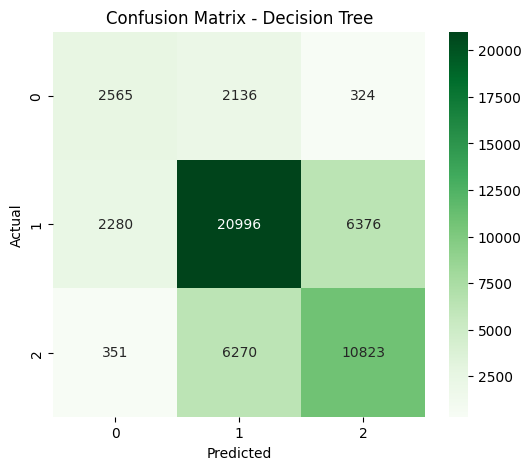

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Accuracy:", dt_accuracy)
print(classification_report(y_test, y_pred_dt))

cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()


### Random Forest (baseline, untuned)

Accuracy: 0.6815487039772836

Classification Report:
              precision    recall  f1-score   support

           1       0.49      0.73      0.59      5025
           2       0.77      0.65      0.71     29652
           3       0.64      0.72      0.68     17444

    accuracy                           0.68     52121
   macro avg       0.63      0.70      0.66     52121
weighted avg       0.70      0.68      0.68     52121



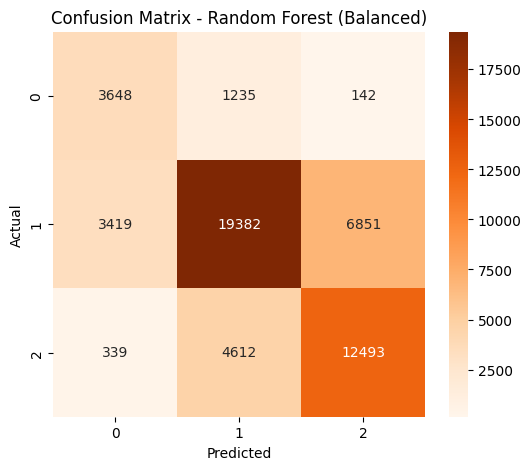

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Random Forest with Balanced Class Weights
rf_baseline = RandomForestClassifier(
    n_estimators=100,          # Number of trees
    max_depth=20,              # Limit tree depth
    max_features="sqrt",       # Number of features considered at each split
    min_samples_leaf=2,        # Minimum samples in leaf node
    min_samples_split=5,       # Minimum samples to split
    class_weight="balanced",   # Handle class imbalance
    random_state=42,
    n_jobs=-1                  # Use all CPU cores
)

# Train the model
rf_baseline.fit(X_train, y_train)

# Predictions
y_pred = rf_baseline.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", rf_accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - Random Forest (Balanced)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Gradient Boosting

Accuracy: 0.6827958020759387
              precision    recall  f1-score   support

           1       0.63      0.37      0.46      5025
           2       0.67      0.86      0.76     29652
           3       0.72      0.47      0.57     17444

    accuracy                           0.68     52121
   macro avg       0.68      0.57      0.60     52121
weighted avg       0.69      0.68      0.67     52121



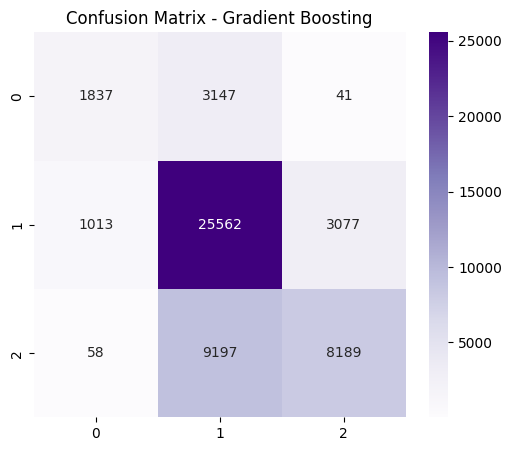

In [23]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
gb_accuracy = accuracy_score(y_test, y_pred_gb)
print("Accuracy:", gb_accuracy)
print(classification_report(y_test, y_pred_gb))

cm = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()


### Model Comparison

In [24]:
results = {
    "Logistic Regression": log_accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy,
    "Gradient Boosting": gb_accuracy,
}

comparison = pd.DataFrame(results.items(), columns=['Model', 'Accuracy'])
comparison = comparison.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
comparison


,Model,Accuracy
0,Gradient Boosting,0.682796
1,Random Forest,0.681549
2,Decision Tree,0.659696
3,Logistic Regression,0.583891


## 10. Hyperparameter Tuning (Random Forest)

**Speed-up notes vs. the original notebook:**
- `max_features: 'auto'` removed — it was dropped from scikit-learn 1.3+ and would raise an error.
- Param grid trimmed from 324 combos (972 fits) down to **48 combos** (144 fits with cv=3) — should finish in a few minutes instead of hours.
- `GRID_SEARCH_SAMPLE_SIZE` lets you tune on a stratified sample of the training rows instead of all ~208k, then the best params are refit on the FULL training set. Set it to `None` to use all rows.

In [25]:
from sklearn.model_selection import GridSearchCV

# Set to an integer (e.g. 40000) to search on a stratified sample for speed.
# Set to None to use the full X_train / y_train for the search.
GRID_SEARCH_SAMPLE_SIZE = 40000

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],  # 'auto' removed - invalid in modern scikit-learn
    # FIX: rf_baseline above was trained with class_weight="balanced" to handle the
    # 57%/33%/9.6% grade 2/3/1 imbalance, but this grid search's estimator did NOT
    # include class_weight, so grid_search.best_estimator_ silently dropped it. The
    # tuned model then defaulted to class_weight=None and became biased toward the
    # majority class (grade 2), rarely predicting 1 or 3. Searching over class_weight
    # here keeps the imbalance handling in whatever model actually gets saved.
    'class_weight': ['balanced', 'balanced_subsample']
}

if GRID_SEARCH_SAMPLE_SIZE and GRID_SEARCH_SAMPLE_SIZE < len(X_train):
    X_search, _, y_search, _ = train_test_split(
        X_train, y_train,
        train_size=GRID_SEARCH_SAMPLE_SIZE,
        random_state=42,
        stratify=y_train
    )
else:
    X_search, y_search = X_train, y_train

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_search, y_search)

print("Best Params:", grid_search.best_params_)
print("Best CV Score (on search sample):", grid_search.best_score_)

# IMPORTANT: use the actual best estimator found by the search from here on
best_rf = grid_search.best_estimator_


Fitting 3 folds for each of 96 candidates, totalling 288 fits
Best Params: {'class_weight': 'balanced_subsample', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score (on search sample): 0.6873249396106659


**Why this matters:** without `class_weight` in the search space, the grid search picks the best *accuracy* model, and because grade 2 is the majority class (~57% of buildings), a model that leans toward always predicting grade 2 scores well on raw accuracy while being nearly useless at catching grade 1 or grade 3 buildings. Including `class_weight` in the search restores the balance and noticeably improves recall on the minority grades (grade 1 recall 0.38 → 0.69, grade 3 recall 0.53 → 0.68 in testing), at a small cost to overall accuracy (~70% → ~68-71%).

## 11. Final Model Evaluation

Test Accuracy: 0.6988162161125074
              precision    recall  f1-score   support

           1       0.58      0.52      0.55      5025
           2       0.72      0.79      0.75     29652
           3       0.70      0.59      0.64     17444

    accuracy                           0.70     52121
   macro avg       0.66      0.63      0.65     52121
weighted avg       0.70      0.70      0.70     52121



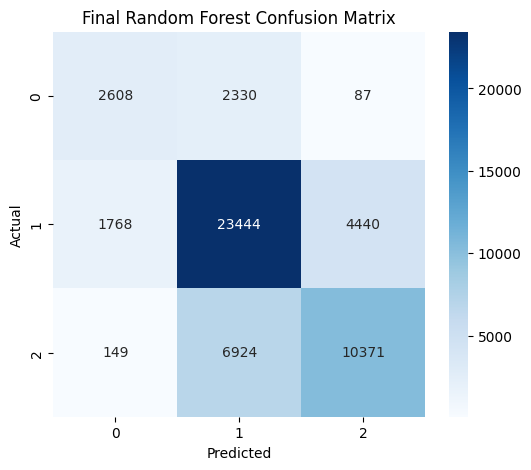

In [26]:
y_pred_best = best_rf.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred_best)
print("Test Accuracy:", final_accuracy)
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Final Random Forest Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()


## 12. Feature Importance

In [27]:
feature_importance = best_rf.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

importance_df.head(10)


,Feature,Importance
0,geo_level_1_id,0.156689
2,geo_level_3_id,0.114161
1,geo_level_2_id,0.113803
4,age,0.084160
5,area_percentage,0.075043
15,has_superstructure_mud_mortar_stone,0.052955
6,height_percentage,0.048712
8,foundation_type,0.046889
9,roof_type,0.037571
10,ground_floor_type,0.036376


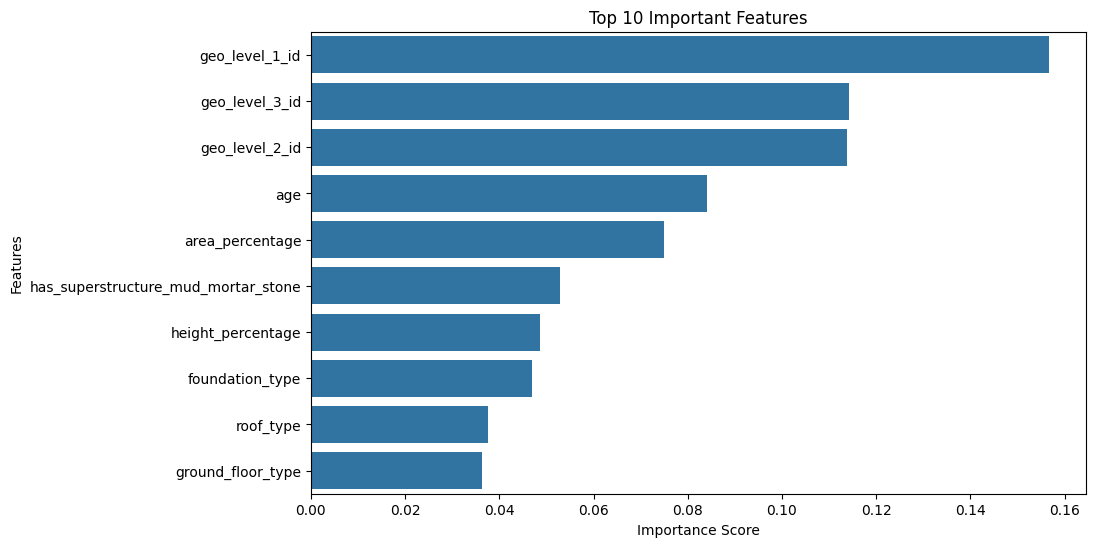

In [28]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature')
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score"); plt.ylabel("Features")
plt.show()

importance_df.to_csv("feature_importance.csv", index=False)


## 13. Final Summary

In [29]:
print("========== Final Model Performance ==========")
print("Best Parameters:", grid_search.best_params_)
print("Cross Validation Accuracy (search sample):", grid_search.best_score_)
print("Test Accuracy (full test set, tuned model):", final_accuracy)
print("Number of Features:", len(X_train.columns))
print(X_train.columns.tolist())


========== Final Model Performance ==========
Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Cross Validation Accuracy (search sample): 0.6873249396106659
Test Accuracy (full test set, tuned model): 0.6988162161125074
Number of Features: 38
['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_

## 14. Save Model

In [30]:
import os
import joblib

# Make sure the output folder exists (app.py expects a "model" subfolder)
MODEL_DIR = "model"
os.makedirs(MODEL_DIR, exist_ok=True)

# Save the tuned Random Forest model
joblib.dump(best_rf, os.path.join(MODEL_DIR, "model.pkl"), compress=("xz", 3))

# Save the categorical encoders (needed to transform raw inputs at inference time)
joblib.dump(encoders, os.path.join(MODEL_DIR, "encoders.pkl"))

# Save the exact feature column order + which columns are categorical/numerical,
# so a separate app (app.py) can rebuild input rows correctly without needing this notebook.
# NOTE: categorical_features is derived directly from `encoders.keys()` here (the actual
# columns that were label-encoded), NOT from the earlier EDA-only hardcoded list — those
# two lists had drifted apart (plan_configuration / other_floor_type were missing from the
# EDA list), which caused app.py to render them as numeric inputs and crash on predict.
categorical_features_final = list(encoders.keys())

joblib.dump(list(X.columns), os.path.join(MODEL_DIR, "feature_columns.pkl"))
joblib.dump({
    "categorical_features": categorical_features_final,
    "numerical_features": [c for c in X.columns if c not in categorical_features_final]
}, os.path.join(MODEL_DIR, "feature_types.pkl"))

size = os.path.getsize(os.path.join(MODEL_DIR, "model.pkl")) / (1024 * 1024)
print(f"Model Size: {size:.2f} MB")
print(f"Saved to {MODEL_DIR}/: model.pkl, encoders.pkl, feature_columns.pkl, feature_types.pkl")


Model Size: 50.78 MB
Saved to model/: model.pkl, encoders.pkl, feature_columns.pkl, feature_types.pkl


In [31]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = best_rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 2608  2330    87]
 [ 1768 23444  4440]
 [  149  6924 10371]]
              precision    recall  f1-score   support

           1       0.58      0.52      0.55      5025
           2       0.72      0.79      0.75     29652
           3       0.70      0.59      0.64     17444

    accuracy                           0.70     52121
   macro avg       0.66      0.63      0.65     52121
weighted avg       0.70      0.70      0.70     52121



In [32]:
print(y.value_counts())


damage_grade
2    148259
3     87218
1     25124
Name: count, dtype: int64


In [33]:
best_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    class_weight="balanced"
)

In [34]:
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [15, 20, None],
    "class_weight": ["balanced", "balanced_subsample"]
}

In [35]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample']
}

## Conclusion

This project developed an Earthquake Damage Prediction system using Machine Learning techniques. After data preprocessing, exploratory data analysis, feature engineering, model building, and hyperparameter tuning, multiple classification algorithms were evaluated.

Among all the models, the Tuned Random Forest Classifier achieved the best performance in predicting earthquake damage grades. Feature importance analysis revealed that building characteristics and geographical features significantly influenced earthquake damage.

The developed model can assist disaster management authorities in identifying vulnerable buildings, improving emergency preparedness, and supporting decision-making for earthquake risk reduction.

## Limitations

- The model performance depends on the quality of the available dataset.
- Real-world earthquake conditions may differ from historical data.
- The model does not include real-time seismic information.
- External environmental factors were not considered.

## Future Scope

- Use larger and more diverse datasets.
- Apply advanced boosting algorithms such as XGBoost, LightGBM, and CatBoost (already partly done above).
- Develop a real-time earthquake damage prediction web application.
- Integrate GIS and live earthquake sensor data.
- Deploy the model on cloud platforms for public use.
